In [8]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import bartlett
from statsmodels.stats.diagnostic import het_breuschpagan


In [9]:
# Simuler des données
np.random.seed(123)
data = pd.DataFrame({
    'group': np.repeat(['A', 'B', 'C'], 10),
    'value': np.concatenate([np.random.normal(5, 1, 10),
                             np.random.normal(6, 1, 10),
                             np.random.normal(7, 1, 10)])
})

In [10]:
# ANOVA
model = ols('value ~ group', data=data).fit()
anova_results = anova_lm(model)

In [11]:
# Indépendance : vérification par le design expérimental

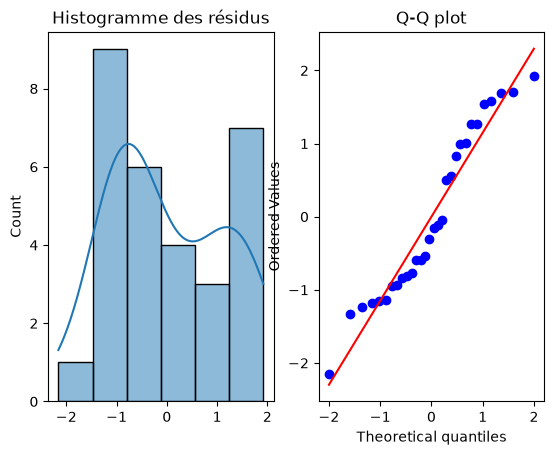

Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.9315106999643349), pvalue=np.float64(0.05386272466149693))


In [12]:
# Normalité des résidus
residuals = model.resid

# Histogramme des résidus
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogramme des résidus')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot')
plt.show()

# Test de normalité
print('Shapiro-Wilk test:', stats.shapiro(residuals))

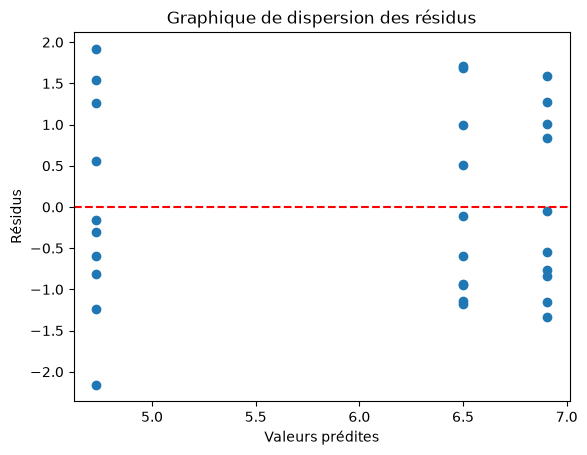

Levene test: LeveneResult(statistic=np.float64(0.05279031470487348), pvalue=np.float64(0.9486765532131478))
Bartlett statistic: 0.3170, p-value: 0.8534


In [13]:
# Homogénéité des variances
# Graphique de dispersion des résidus
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.title('Graphique de dispersion des résidus')
plt.show()

# Tests de Levene et Bartlett
print('Levene test:', stats.levene(data['value'][data['group'] == 'A'],
                                   data['value'][data['group'] == 'B'],
                                   data['value'][data['group'] == 'C']))

stat, p_value = bartlett(data['value'][data['group'] == 'A'],
                         data['value'][data['group'] == 'B'],
                         data['value'][data['group'] == 'C'])
print(f"Bartlett statistic: {stat:.4f}, p-value: {p_value:.4f}")